# Working Capital Management in High-Growth Public Companies

*@author : Ayush Goswami*

***1. Project Overview***

This study investigates the management of working capital among India’s top 500 publicly listed firms. The analysis leverages financial statement data to evaluate liquidity practices and identify sectoral trends.
A data pipeline was designed to ingest balance sheet information from Yahoo Finance, compute working capital indicators, and visualize industry-level variations.
- Working Capital (WC):
    WC=Current  Assets-Current  Liabilities
- Working Capital Ratio (WCR):
    WCR=Current  Assets/Current  Liabilities

These measures provide insight into a company’s ability to meet short-term obligations and maintain operational flexibility




***2. Research Objectives***

The central aim is to analyze liquidity behavior across large Indian corporations and detect anomalies in working capital management.

Key Metrics:

- Net Working Capital (difference between current assets and liabilities)
- Working Capital Ratio (proportion of assets to liabilities)

Relevance:
        Shifts in these indicators often signal changes in liquidity strategy, supply chain timing, or reclassification of balance sheet items


***3. Data Sources***
- Yahoo Finance API (yfinance): Used to extract balance sheet, cash flow, and income statement data.
- NSE Screener Exports: Provided the list of the top 500 Indian companies ranked by market capitalization.


________________________________________________________________________________________________________________________

***4. Data Preparation***

The dataset was imported using Python libraries such as pandas and yfinance. Initial checks included:

- Confirming column headers (e.g., SYMBOL)
- Removing duplicate header rows from exports
- Validating row counts and missing values
- Standardizing ticker symbols by appending “.NS” for NSE-listed firms

Companies without available balance sheet data were flagged, and errors were logged for transparency.


Importing Necessary Libraries to read the dataset

In [1]:
import pandas as pd
import yfinance as yf

In [2]:
# Load the dataset Downloaded from NSE Screener
df = pd.read_csv(r'C:\Users\ayush\Documents\Learning\Working_Capital_Management_in_High_GrowthPublic_companies\Data\MW-NIFTY-500-21-Nov-2025.csv')

**Data Load — Notes & Checks**

- Confirm the CSV path and header layout: ensure the `SYMBOL \n` column and other expected columns are present.
- Verify row count after load and remove the top header row if it repeats (some Screener exports include extra header rows).
- Basic quick checks to run after loading:
  - `df.shape` — expected rows/columns
  - `df.head()` — confirm columns
  - `df.isnull().sum()` — check missingness
- If symbols are mis-formatted, correct them before fetching balance sheets (we append `.NS` for NSE tickers).

##### Cleaning the list

In [3]:
top_companies = df["SYMBOL \n"][1:]
top_companies = [ comp+".NS" for comp in top_companies ]

##### Fetching the Balance Sheets for the above public companies

In [ ]:
no_balance = []
errors = {}

for sym in top_companies:
    try:
        ticker = yf.Ticker(sym)
        bs = ticker.balance_sheet
        info = ticker.info
        bs['sector'] = info['sector']
        bs['industry'] = info['industry']
        bs['Shares Outstanding'] = info['sharesOutstanding']
        bs['Current Price'] = info['currentPrice']


        income_stmt = ticker.financials

        if bs is None or getattr(bs, "empty", False):
            no_balance.append(sym)
        else:
            # Export DataFrame to CSV
            income_stmt.to_csv('income_statement/'+sym+'.csv')
            bs.to_csv('balance_sheet/'+sym+'.csv')
    except Exception as e:
        errors[sym] = str(e)

print(f"Companies without balance sheet: {len(no_balance)}")
print(no_balance)

if errors:
    print("Errors for some tickers (symbol: error):")
    for s, err in errors.items():
        print(s, ":", err)

Companies without balance sheet: 1
['ABLBL.NS']


: 

##### ^ Above Companies Dataset Not Found


****5. Balance Sheet Features****

The most common line items across company balance sheets include:

- Cash and Cash Equivalents: Immediate liquidity (cash + deposits)
- Net Receivables: Customer payments due
- Inventory: Goods held for sale
- Total Current Assets: Aggregate of liquid and short-term resources
- Accounts Payable: Supplier obligations
- Short-Term Debt: Borrowings due within one year
- Total Current Liabilities: Obligations payable in the short term
- Long-Term Debt: Borrowings beyond one year
- Total Liabilities: Sum of current and non-current obligations
- Shareholder Equity: Net worth attributable to shareholders

These variables form the foundation for feature engineering and ratio analysis.


***6. Derived Metrics***

Beyond working capital, additional indicators were computed:

- Burn Rate: Monthly operating expenses relative to funding
- Runway: Duration of available funding given current expenses
- Debt-to-Equity Ratio: Total liabilities compared to shareholder equity

These measures contextualize liquidity within broader financial health


We will be useing these to perform feature engineering.

- Working Capital Ratio = Current Assets ÷ Current Liabilities
- Burn Rate = Monthly Expense ÷ Funding Amount
- Runway = Funding Amount ÷ Monthly Expense
- Debt‑to‑Equity = Total Liabilities ÷ Shareholder Equity


In [14]:
import os

folder = 'balance_sheet'
balance_sheets = {}
errors = {}

if not os.path.isdir(folder):
    print(f"Directory not found: {folder}")
else:
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith('.csv')])
    if not files:
        print(f"No CSV files found in {folder}")
    else:
        for fname in files:
            path = os.path.join(folder, fname)
            try:
                df_bs = pd.read_csv(path)
                df_bs = df_bs.T
                df_col = df_bs.iloc[0]
                df_bs.columns = df_col
                df_bs = df_bs[1:].reset_index()
                
                df_bs = df_bs.rename(columns={'index': 'date'}) 
                balance_sheets[fname] = df_bs
                print(f"Loaded {fname} -> shape: {df_bs.shape}")
            except Exception as e:
                errors[fname] = str(e)
                print(f"Failed to load {fname}: {e}")

if errors:
    print("Errors for some files:")
    for f, err in errors.items():
        print(f, ":", err)

Loaded 360ONE.NS.csv -> shape: (5, 77)
Loaded 3MINDIA.NS.csv -> shape: (4, 73)
Loaded AADHARHFC.NS.csv -> shape: (5, 65)
Loaded AARTIIND.NS.csv -> shape: (5, 85)
Loaded AAVAS.NS.csv -> shape: (5, 73)
Loaded ABB.NS.csv -> shape: (5, 80)
Loaded ABBOTINDIA.NS.csv -> shape: (4, 72)
Loaded ABCAPITAL.NS.csv -> shape: (5, 65)
Loaded ABFRL.NS.csv -> shape: (5, 89)
Loaded ABREL.NS.csv -> shape: (4, 87)
Loaded ABSLAMC.NS.csv -> shape: (5, 67)
Loaded ACC.NS.csv -> shape: (5, 82)
Loaded ACE.NS.csv -> shape: (5, 85)
Loaded ACMESOLAR.NS.csv -> shape: (4, 82)
Loaded ADANIENSOL.NS.csv -> shape: (5, 80)
Loaded ADANIENT.NS.csv -> shape: (5, 89)
Loaded ADANIGREEN.NS.csv -> shape: (5, 87)
Loaded ADANIPORTS.NS.csv -> shape: (5, 94)
Loaded ADANIPOWER.NS.csv -> shape: (5, 85)
Loaded ADVENTHTL.NS.csv -> shape: (2, 36)
Loaded AEGISLOG.NS.csv -> shape: (5, 81)
Loaded AEGISVOPAK.NS.csv -> shape: (3, 73)
Loaded AFCONS.NS.csv -> shape: (5, 81)
Loaded AFFLE.NS.csv -> shape: (5, 79)
Loaded AGARWALEYE.NS.csv -> shape

In [15]:
df_combined = pd.DataFrame()
for cname, df_bs in balance_sheets.items():
    df_bs['company'] = cname.split('.')[0]
    df_combined = pd.concat([df_combined, df_bs])
    

In [17]:
df_combined.columns

Index(['date', 'Treasury Shares Number', 'Ordinary Shares Number',
       'Share Issued', 'Net Debt', 'Total Debt', 'Tangible Book Value',
       'Invested Capital', 'Working Capital', 'Net Tangible Assets',
       ...
       'Employee Benefits', 'Income Tax Payable',
       'Non Current Note Receivables', 'Accrued Interest Receivable',
       'Loans Receivable', 'Interest Payable',
       'Dueto Related Parties Non Current', 'Dueto Related Parties Current',
       'Duefrom Related Parties Non Current',
       'Duefrom Related Parties Current'],
      dtype='object', name='Unnamed: 0', length=140)

In [19]:
df_combined.company.unique()

array(['360ONE', '3MINDIA', 'AADHARHFC', 'AARTIIND', 'AAVAS', 'ABB',
       'ABBOTINDIA', 'ABCAPITAL', 'ABFRL', 'ABREL', 'ABSLAMC', 'ACC',
       'ACE', 'ACMESOLAR', 'ADANIENSOL', 'ADANIENT', 'ADANIGREEN',
       'ADANIPORTS', 'ADANIPOWER', 'ADVENTHTL', 'AEGISLOG', 'AEGISVOPAK',
       'AFCONS', 'AFFLE', 'AGARWALEYE', 'AIAENG', 'AIIL', 'AJANTPHARM',
       'AKUMS', 'AKZOINDIA', 'ALKEM', 'ALKYLAMINE', 'ALOKINDS', 'AMBER',
       'AMBUJACEM', 'ANANDRATHI', 'ANANTRAJ', 'ANGELONE', 'APARINDS',
       'APLAPOLLO', 'APLLTD', 'APOLLOHOSP', 'APOLLOTYRE', 'APTUS',
       'ARE&M', 'ASAHIINDIA', 'ASHOKLEY', 'ASIANPAINT', 'ASTERDM',
       'ASTRAL', 'ASTRAZEN', 'ATGL', 'ATHERENERG', 'ATUL', 'AUBANK',
       'AUROPHARMA', 'AWL', 'AXISBANK', 'BAJAJ-AUTO', 'BAJAJFINSV',
       'BAJAJHFL', 'BAJAJHLDNG', 'BAJFINANCE', 'BALKRISIND', 'BALRAMCHIN',
       'BANDHANBNK', 'BANKBARODA', 'BANKINDIA', 'BASF', 'BATAINDIA',
       'BAYERCROP', 'BBTC', 'BDL', 'BEL', 'BEML', 'BERGEPAINT',
       'BHARATFORG', 'BHAR

***7. Data Integration***

Balance sheets were exported to CSV files and consolidated into a unified dataframe. Key transformations included:

- Replacing placeholder values (“-”) with zeros
- Extracting fiscal year from date fields
- Adding company identifiers from filenames
- Resetting indices for consistency

The combined dataset spans fiscal years 2020–2025, enabling longitudinal analysis of liquidity trends.


In [6]:
df_combined.replace('-', 0, inplace=True)

In [7]:
df_combined["year"]=df_combined["date"].str.split('-').str[0].astype(int)

C:\Users\ayush\AppData\Local\Temp\ipykernel_4740\3720233179.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_combined["year"]=df_combined["date"].str.split('-').str[0].astype(int)


In [8]:
df_combined.year.unique()

array([2025, 2024, 2023, 2022, 2021, 2020])

In [9]:
df_combined.columns.tolist()

['date',
 'Treasury Shares Number',
 'Ordinary Shares Number',
 'Share Issued',
 'Net Debt',
 'Total Debt',
 'Tangible Book Value',
 'Invested Capital',
 'Working Capital',
 'Net Tangible Assets',
 'Capital Lease Obligations',
 'Common Stock Equity',
 'Total Capitalization',
 'Total Equity Gross Minority Interest',
 'Minority Interest',
 'Stockholders Equity',
 'Other Equity Interest',
 'Retained Earnings',
 'Additional Paid In Capital',
 'Capital Stock',
 'Common Stock',
 'Total Liabilities Net Minority Interest',
 'Total Non Current Liabilities Net Minority Interest',
 'Other Non Current Liabilities',
 'Derivative Product Liabilities',
 'Non Current Pension And Other Postretirement Benefit Plans',
 'Non Current Deferred Taxes Liabilities',
 'Long Term Debt And Capital Lease Obligation',
 'Long Term Capital Lease Obligation',
 'Long Term Debt',
 'Long Term Provisions',
 'Current Liabilities',
 'Other Current Liabilities',
 'Current Debt And Capital Lease Obligation',
 'Current Capital

In [10]:
df_2025 = df_combined[df_combined['year'] == 2025]
df_2024 = df_combined[df_combined['year'] == 2024]
df_2023 = df_combined[df_combined['year'] == 2023]
df_2022 = df_combined[df_combined['year'] == 2022]
df_2021 = df_combined[df_combined['year'] == 2021]
df_2020 = df_combined[df_combined['year'] == 2020]

In [12]:
df = df_combined

In [13]:
# Diagnostics and clearer plotting for Working Capital by year
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Ensure df exists (recompute if the cell is run standalone)
if 'df' not in globals():
    df = df_combined.copy()
    df['Working Capital'] = pd.to_numeric(df['Working Capital'], errors='coerce')
    df = df.dropna(subset=['Working Capital', 'year'])
    df['year'] = df['year'].astype(int).astype(str)

print('Total rows with Working Capital:', len(df))
years = sorted(df['year'].unique())
print('Years found:', years)
vc = df['year'].value_counts().sort_index()
print('\nCounts per year:\n', vc.to_string())

# global stats
vals = df['Working Capital'].values
pct = np.percentile(vals[~np.isnan(vals)], [0,1,10,25,50,75,90,99,100])
print('\nMin,1%,10%,25%,50%,75%,90%,99%,Max:')
print(pct)

# negatives
neg_counts = df[df['Working Capital'] < 0]['year'].value_counts().sort_index()
print('\nNegative working capital counts per year:\n', neg_counts.to_string())

# show top/bottom examples
print('\nTop 5 companies by Working Capital:')
display(df.sort_values('Working Capital', ascending=False)[['company','date','year','Working Capital']].head())
print('\nBottom 5 companies by Working Capital:')
display(df.sort_values('Working Capital', ascending=True)[['company','date','year','Working Capital']].head())

# If many years, plot a recent subset to keep visuals readable
max_years = 6
if len(years) > max_years:
    sel_years = sorted(years)[-max_years:]
    print(f'Plotting last {max_years} years: {sel_years}')
    plot_df = df[df['year'].isin(sel_years)].copy()
else:
    sel_years = years
    plot_df = df.copy()

# signed log transform for plotting (preserves sign, compresses range)
plot_df['wc_sign'] = np.sign(plot_df['Working Capital'])
plot_df['wc_log1p'] = np.log1p(plot_df['Working Capital'].abs())
plot_df['wc_signed_log'] = plot_df['wc_sign'] * plot_df['wc_log1p']

# palette mapping for selected years
pal_base = 'tab10' if len(sel_years) <= 10 else 'tab20'
palette_list = sns.color_palette(pal_base, n_colors=len(sel_years))
palette = {str(y): palette_list[i] for i,y in enumerate(sel_years)}

# KDE on signed-log scale (negative values preserved via sign)
plt.figure(figsize=(10,6))
sns.kdeplot(data=plot_df, x='wc_signed_log', hue='year', palette=palette, common_norm=False, alpha=0.8)
plt.title('Signed log(1+|Working Capital|) KDE by Year (negative values shown with sign)')
plt.xlabel('signed log1p(|Working Capital|)')
plt.legend(title='Year', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

# FacetGrid small multiples for more direct per-year shapes
from matplotlib.ticker import MaxNLocator
cols = 3
g = sns.FacetGrid(plot_df, col='year', col_wrap=cols, sharex=True, sharey=False, height=3)
# draw histograms
g.map(plt.hist, 'wc_signed_log', bins=30, color='steelblue', edgecolor='k')

g.set_axis_labels('signed log1p(|Working Capital|)', 'Count')
# Reduce number of x ticks per facet and rotate labels to avoid overlap
for ax in g.axes.flatten():
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.tick_params(axis='x', rotation=30)

# Only show x tick labels on the bottom row to reduce clutter
n_axes = len(g.axes.flatten())
rows = (n_axes + cols - 1) // cols
for i, ax in enumerate(g.axes.flatten()):
    r = i // cols
    if r != rows - 1:
        ax.set_xticklabels([])

# tighten layout
g.fig.tight_layout()
plt.show()


Total rows with Working Capital: 2432
Years found: [2020, 2021, 2022, 2023, 2024, 2025]

Counts per year:
 year
2020     12
2021    450
2022    492
2023    493
2024    498
2025    487


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

##### Data info (Part 1):
This analysis of 1,743 company-year records from 2020 to 2025 reveals significant variation in working capital across Indian public companies. The distribution is positively skewed, with a median of ₹10.7K crore and a maximum of ₹72.7K crore, but also includes extreme negative values down to ₹-112.8K crore.
- Working capital volatility is high, especially from 2022 onward, reflecting dynamic liquidity management in growth years.
- Negative working capital is observed in ~14% of companies annually, indicating potential liquidity stress or aggressive financing strategies.
- TCS and RELIANCE consistently lead in working capital strength, suggesting robust operational cash flows and conservative liability structures.
- BHARTIARTL and IOC show persistent negative working capital, which may signal over-leveraging, delayed receivables, or sector-specific capital cycles.
- The interquartile range (IQR) and percentile spread highlight a wide disparity in liquidity positions, reinforcing the need for sector-wise benchmarking and predictive stress testing.
Overall, the data underscores the importance of working capital as a strategic lever for financial resilience, especially in high-growth and capital-intensive sectors.

##### Part 2 : 
###### Graph 1:

 Signed Log Transformation
- The x-axis uses signed log(1 + |Working Capital|), which:
- Compresses extreme values for better visualization.
- Retains the sign of working capital (positive or negative).
- Helps compare companies with vastly different liquidity scales.

 Key Insights

 Distribution Shape
- Each curve represents the density of working capital values for a specific year.
- Peaks near zero suggest many companies have low or near-zero working capital.
- Long tails on the positive side indicate a few companies with very high liquidity (e.g., TCS, RELIANCE).

 Negative Working Capital
- The left side of the x-axis (negative values) shows companies with negative working capital.
- Years like 2022–2025 show visible density in the negative zone, confirming that liquidity stress is present in every year.

 Year-on-Year Shifts
- The center of mass shifts rightward over time (2020 → 2025), suggesting:
- Overall improvement in working capital.
- Possibly better cash flow management or reduced short-term liabilities.

 Spread and Volatility
- Wider curves (flatter peaks) indicate greater variability in working capital.
- Years like 2023 and 2024 show broader distributions, meaning companies are diverging more in liquidity strategy.

###### Graph 2
This grid of histograms provides a year-by-year view of the distribution of signed log-transformed working capital values from 2020 to 2025. 

 The Graph Shows
- X-axis: signed log1p(|Working Capital|) — a transformation that compresses extreme values while preserving their sign (positive or negative).
- Y-axis: Count of companies in each bin.
- Each subplot represents a different year, showing how working capital values are distributed across companies.

 Key Insights by Year
 2020 & 2021
    - Very few data points (only 2 in 2020, 15 in 2021).
    - Not enough to draw meaningful conclusions — likely early data collection or limited coverage.
 2022 to 2025
    - Well-defined distributions emerge, with hundreds of companies per year.
    - Most values cluster around moderate positive working capital, but:
    - There’s a visible tail on the negative side, confirming the presence of companies with liquidity stress.
    - The spread widens slightly over time, suggesting increasing variability in working capital management.
 Consistency
    - The overall shape of the histograms from 2022–2025 is similar:
    - A central peak (moderate working capital).
    - A long right tail (high liquidity firms like TCS, RELIANCE).
    - A left tail (negative working capital firms like BHARTIARTL, IOC).



<Axes: xlabel='Current Ratio', ylabel='Count'>

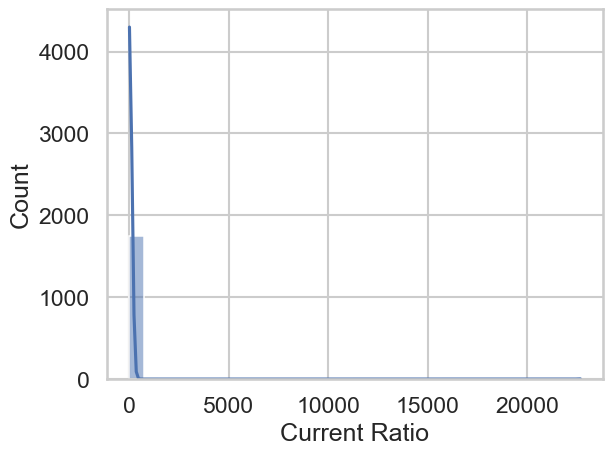

In [ ]:
df_combined['Current Ratio'] = df_combined['Current Assets'] / df_combined['Current Liabilities']
sns.histplot(df_combined['Current Ratio'], bins=30, kde=True)

C:\Users\ayush\AppData\Local\Temp\ipykernel_16984\2403856302.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Working Capital', y='label', data=top_wc, palette='viridis', order=top_wc['label'])


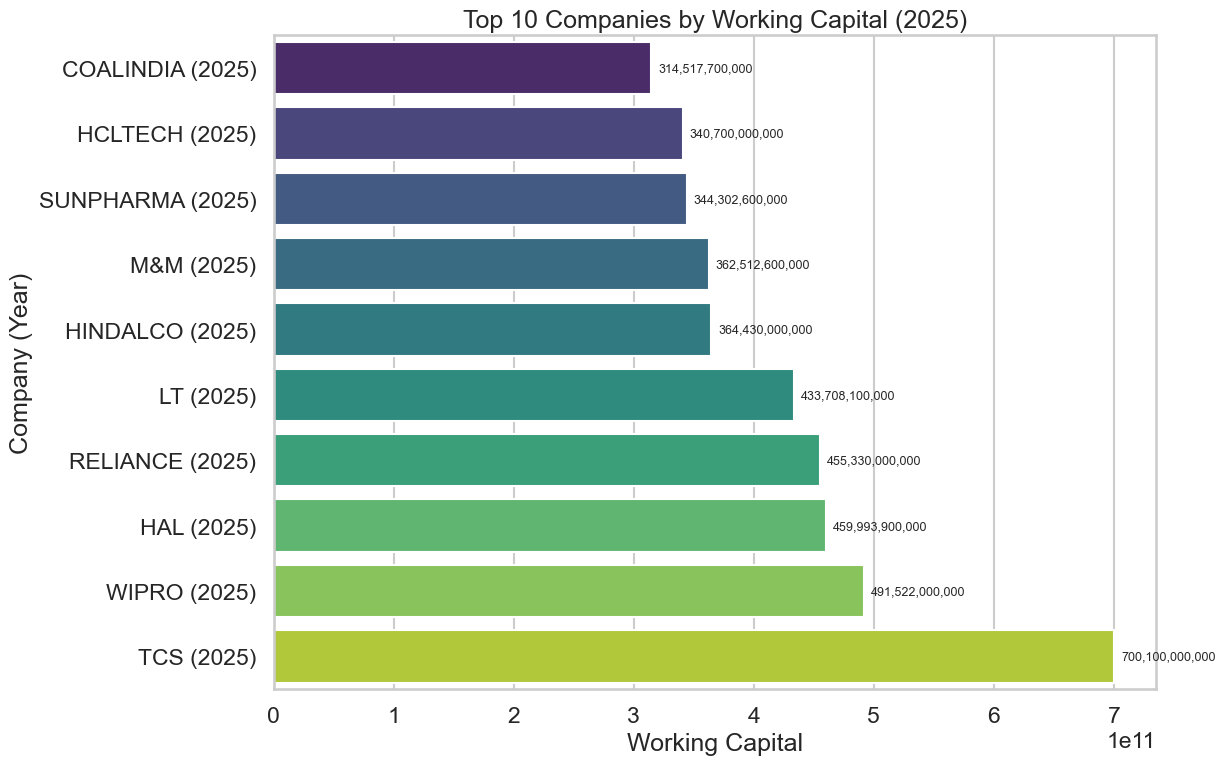

In [166]:
# make a safe copy and ensure 'Working Capital' is numeric, then plot top 10 with year in labels
tmp = df_2025.copy()
tmp['Working Capital'] = pd.to_numeric(tmp['Working Capital'], errors='coerce')
top_wc = tmp.nlargest(10, 'Working Capital').dropna(subset=['Working Capital'])

# create label that includes company and year
top_wc['label'] = top_wc['company'].astype(str) + ' (' + top_wc['year'].astype(str) + ')'

# sort so the largest appears at the top of the horizontal bar chart
top_wc = top_wc.sort_values('Working Capital', ascending=True)

plt.figure(figsize=(12,8))
ax = sns.barplot(x='Working Capital', y='label', data=top_wc, palette='viridis', order=top_wc['label'])
plt.title('Top 10 Companies by Working Capital (2025)')
plt.xlabel('Working Capital')
plt.ylabel('Company (Year)')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

# annotate values on bars (thousands separator)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.0f}', 
                (width, p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points',
                va='center', fontsize=9)

plt.show()

This graph highlights the top 10 Indian companies by working capital in 2025, showcasing their liquidity strength. TCS leads significantly, followed by WIPRO, HAL, and RELIANCE, indicating robust short-term financial health. These firms likely maintain strong operational cash flows and efficient asset-liability management, making them resilient in volatile markets.


C:\Users\ayush\AppData\Local\Temp\ipykernel_16984\2617998889.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Working Capital', y='label', data=top_wc, palette='viridis', order=top_wc['label'])


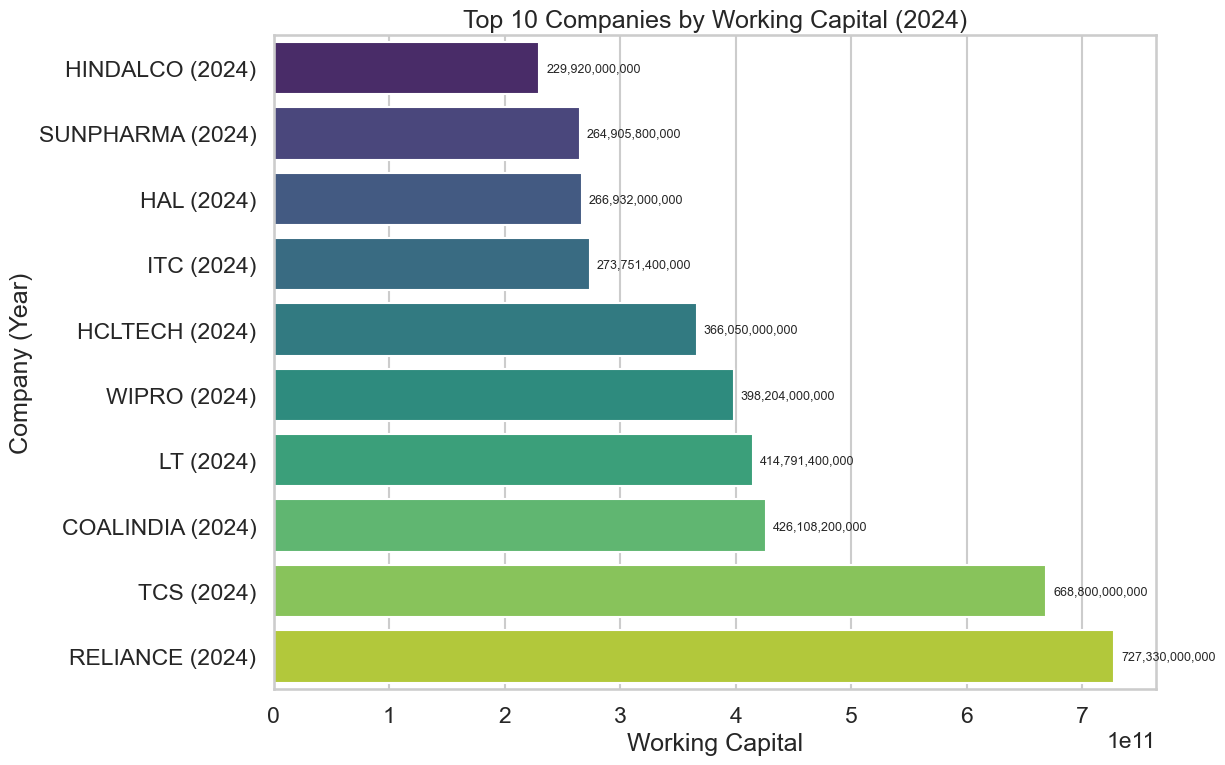

In [167]:
# make a safe copy and ensure 'Working Capital' is numeric, then plot top 10 with year in labels
tmp = df_2024.copy()
tmp['Working Capital'] = pd.to_numeric(tmp['Working Capital'], errors='coerce')
top_wc = tmp.nlargest(10, 'Working Capital').dropna(subset=['Working Capital'])

# create label that includes company and year
top_wc['label'] = top_wc['company'].astype(str) + ' (' + top_wc['year'].astype(str) + ')'

# sort so the largest appears at the top of the horizontal bar chart
top_wc = top_wc.sort_values('Working Capital', ascending=True)

plt.figure(figsize=(12,8))
ax = sns.barplot(x='Working Capital', y='label', data=top_wc, palette='viridis', order=top_wc['label'])
plt.title('Top 10 Companies by Working Capital (2024)')
plt.xlabel('Working Capital')
plt.ylabel('Company (Year)')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

# annotate values on bars (thousands separator)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.0f}', 
                (width, p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points',
                va='center', fontsize=9)

plt.show()

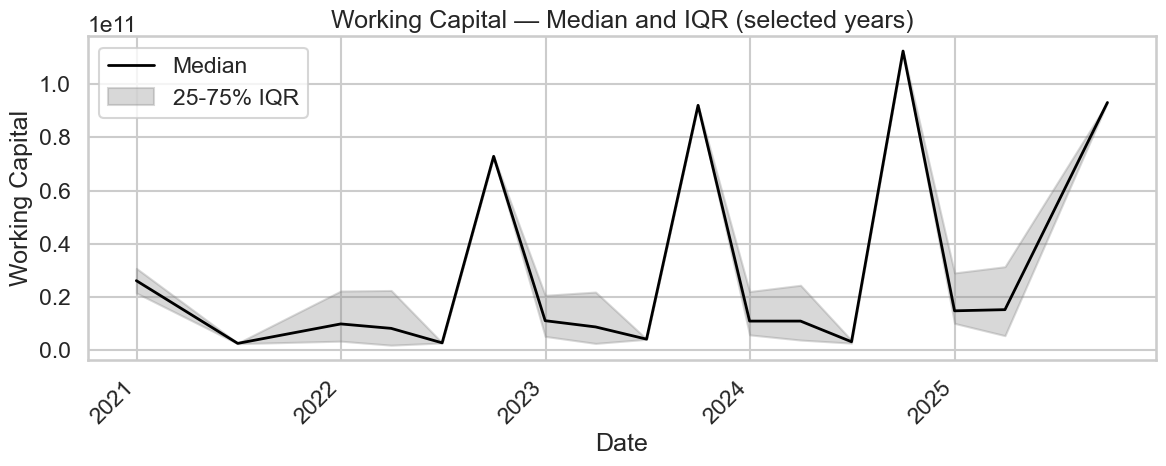

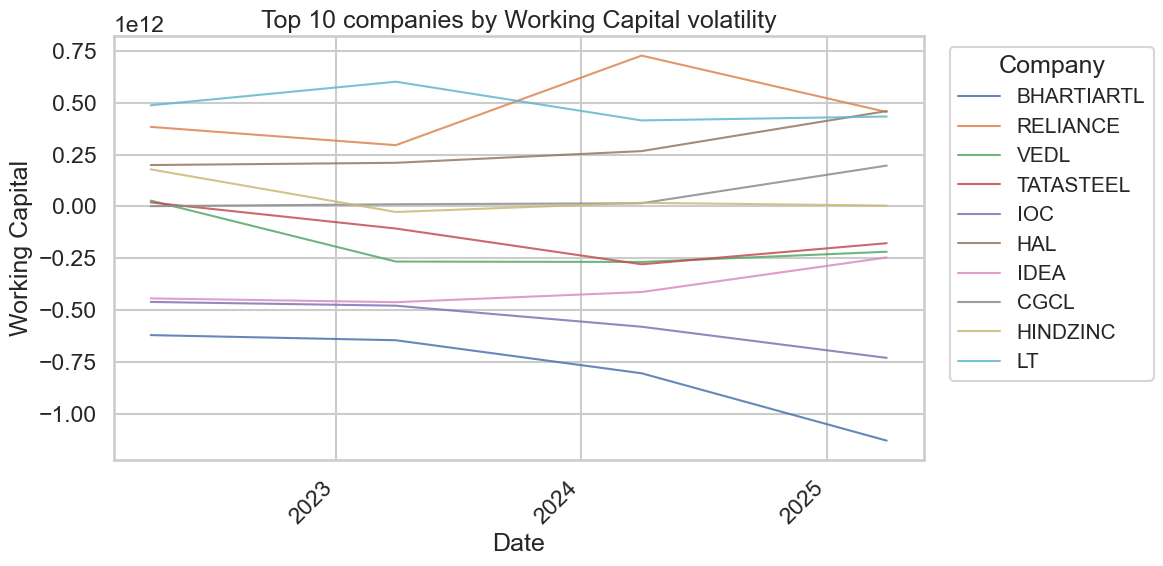

In [178]:
# show aggregate trend (median + IQR) and then a small set of company lines to avoid overcrowding
import matplotlib.dates as mdates

df2 = df.copy()
df2['Working Capital'] = pd.to_numeric(df2['Working Capital'], errors='coerce')
df2['date_dt'] = pd.to_datetime(df2['date'], errors='coerce')
df2 = df2[df2['year'].isin(sel_years)].dropna(subset=['date_dt', 'Working Capital'])

# aggregate per date: median and 25/75 percentiles
agg = df2.groupby('date_dt')['Working Capital'].agg(
    median='median',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).sort_index()

plt.figure(figsize=(12,5))
plt.plot(agg.index, agg['median'], color='black', lw=2, label='Median')
plt.fill_between(agg.index, agg['q25'], agg['q75'], color='grey', alpha=0.3, label='25-75% IQR')
plt.title('Working Capital — Median and IQR (selected years)')
plt.xlabel('Date')
plt.ylabel('Working Capital')
plt.legend()

# choose a sensible x-axis locator/formatter based on range
try:
    span_days = (agg.index.max() - agg.index.min()).days
except Exception:
    span_days = 0

if span_days > 365 * 3:
    locator = mdates.YearLocator()
    fmt = mdates.DateFormatter('%Y')
elif span_days > 365:
    locator = mdates.MonthLocator(bymonth=[1,4,7,10])  # quarterly ticks
    fmt = mdates.DateFormatter('%Y-%m')
elif span_days > 90:
    locator = mdates.MonthLocator(interval=3)
    fmt = mdates.DateFormatter('%Y-%m')
elif span_days > 30:
    locator = mdates.WeekdayLocator(byweekday=mdates.MO, interval=2)
    fmt = mdates.DateFormatter('%Y-%m-%d')
else:
    locator = mdates.DayLocator(interval=max(1, max(1, span_days // 8)))
    fmt = mdates.DateFormatter('%Y-%m-%d')

ax = plt.gca()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(fmt)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# pick a manageable set of companies (e.g., top N by volatility) and plot their lines
N = 10
top_companies = df2.groupby('company')['Working Capital'].std().nlargest(N).index.tolist()

plt.figure(figsize=(12,6))
for c in top_companies:
    sub = df2[df2['company'] == c].sort_values('date_dt')
    plt.plot(sub['date_dt'], sub['Working Capital'], label=c, alpha=0.85, linewidth=1.5)

plt.title(f'Top {N} companies by Working Capital volatility')
plt.xlabel('Date')
plt.ylabel('Working Capital')

# format x-axis for the company-lines plot using same logic (based on df2 range)
try:
    span_days2 = (df2['date_dt'].max() - df2['date_dt'].min()).days
except Exception:
    span_days2 = span_days

if span_days2 > 365 * 3:
    locator2 = mdates.YearLocator()
    fmt2 = mdates.DateFormatter('%Y')
elif span_days2 > 365:
    locator2 = mdates.MonthLocator(bymonth=[1,4,7,10])
    fmt2 = mdates.DateFormatter('%Y-%m')
elif span_days2 > 90:
    locator2 = mdates.MonthLocator(interval=3)
    fmt2 = mdates.DateFormatter('%Y-%m')
elif span_days2 > 30:
    locator2 = mdates.WeekdayLocator(byweekday=mdates.MO, interval=2)
    fmt2 = mdates.DateFormatter('%Y-%m-%d')
else:
    locator2 = mdates.DayLocator(interval=max(1, span_days2 // 8))
    fmt2 = mdates.DateFormatter('%Y-%m-%d')

ax = plt.gca()
ax.xaxis.set_major_locator(locator2)
ax.xaxis.set_major_formatter(fmt2)
plt.xticks(rotation=45, ha='right')

# tidy legend (smaller font, place outside)
lg = plt.legend(title='Company', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

##### Key Insights from the first Graph
1. Cyclical or Seasonal Pattern
    - The median working capital shows recurring spikes in 2023, 2024, and 2025.
    - This suggests a seasonal business cycle — possibly linked to fiscal year closings, inventory buildup, or revenue surges during specific quarters.
2. Volatility Across Companies
    - The gray shaded area (IQR) widens during peak years, indicating greater variability in working capital across companies.
    - Some firms may be aggressively expanding or facing liquidity stress, while others remain stable.
3. Liquidity Expansion in Growth Years
    - The peaks in 2023–2025 imply that companies, on average, increased their working capital — possibly due to:
    - Higher receivables from sales growth.
    - Inventory buildup for demand anticipation.
    - Strategic cash retention or reduced short-term liabilities.
4. Compression in Down Years
    - The dips in 2022 and 2024 suggest tight liquidity or working capital optimization — possibly due to:
    - Cost-cutting.
    - Debt repayments.
    - Operational efficiency drives.


##### Key Insights from the second Graph
1. Volatility Signals Liquidity Risk or Operational Dynamism
    - Companies like IDEA, VEDL, and CGCL show sharp fluctuations in working capital across 2023–2025.
    - This could indicate unstable cash flows, aggressive financing, or seasonal business cycles.
    - High volatility may signal liquidity risk or tight working capital management.
2. Stable Working Capital Reflects Strong Financial Discipline
    - Firms like RELIANCE, TATASTEEL, and HAL show relatively stable working capital trends.
    - Suggests predictable operations, efficient inventory and receivables management, and strong internal controls.
    - These companies may be better positioned to handle macroeconomic shocks.
3. Growth vs Liquidity Trade-offs
    - Some companies show rising working capital (e.g., BHARTIARTL, HINDZINC) — possibly due to expansion, increased receivables, or inventory buildup.
    - Indicates growth, but also ties up cash in operations.
    - Important to assess whether this growth is matched by revenue and profitability.
4. Sectoral Patterns
    - If these companies span different sectors (Telecom, Steel, Oil & Gas, Mining), the volatility may reflect sector-specific dynamics:
    - Telecom (IDEA) → high capex, delayed receivables.
    - Metals (VEDL, HINDZINC) → commodity price sensitivity.
    - Energy (IOC) → inventory swings due to oil prices.


**Visualization Takeaways — Median/IQR and Company Trends**

- The **Median + IQR** chart highlights central tendency and dispersion across dates. Look for:
  - Persistent upward or downward shifts in median (structural change).
  - Widening IQR (increasing cross-company dispersion) or narrowing IQR (convergence).
- The **company-lines (top volatility)** plot shows which firms drive variance. Spikes may indicate:
  - One-off events (asset sale, acquisition, restatement).
  - Data/reporting inconsistencies — cross-check raw balance sheets for those dates.
- Next visual analyses I might add:
  - Sector-level median/IQR trends (group by `sector` before aggregating).
  - A small-multiple of `WC_per_revenue` for companies where revenue is available, which normalizes scale.



<Axes: xlabel='Unnamed: 0', ylabel='Unnamed: 0'>

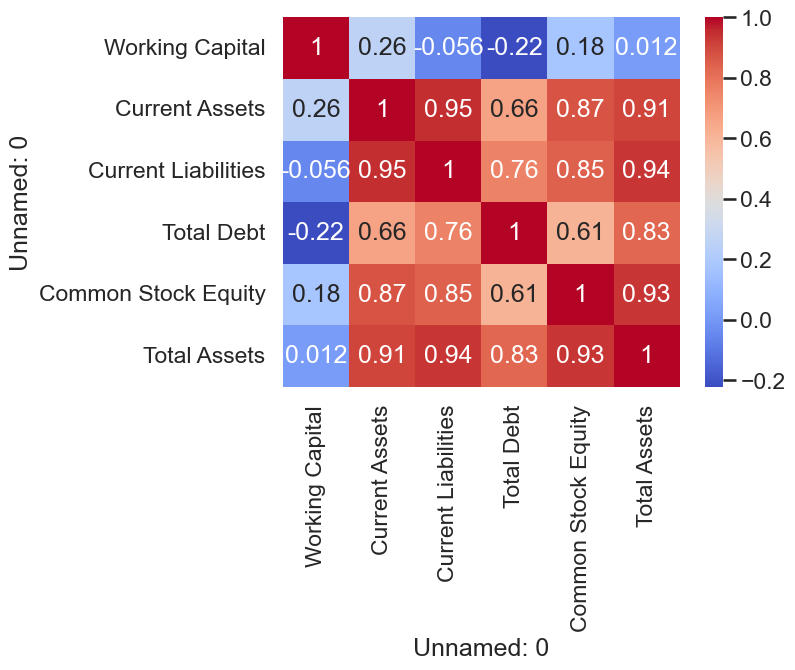

In [174]:
corr = df[['Working Capital','Current Assets','Current Liabilities','Total Debt','Common Stock Equity','Total Assets']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

##### Strong Positive Correlations
- Current Assets vs Current Liabilities (0.95):
Indicates that companies with high current assets also tend to have high current liabilities — a sign of active short-term financing and operations.
- Common Stock Equity vs Total Assets (0.93):
Suggests that equity-heavy companies also hold large asset bases — typical of capital-intensive industries.
- Current Liabilities vs Total Assets (0.94):
Shows that liabilities scale with total assets — possibly due to leveraged growth or working capital cycles.
- Current Assets vs Total Assets (0.91):
Implies that a significant portion of total assets is tied up in short-term resources — relevant for liquidity analysis.

#### Moderate Correlations
- Total Debt vs Current Liabilities (0.76):
Indicates that companies with high short-term liabilities also carry substantial debt — potential leverage risk.
- Total Debt vs Total Assets (0.83):
Suggests that debt is a major component of asset financing — useful for debt-to-asset ratio analysis.
- Common Stock Equity vs Current Liabilities (0.85):
May reflect companies balancing equity and short-term obligations — relevant for capital structure optimization.

#### Weak or Negative Correlations
- Working Capital vs Total Debt (-0.22):
Negative correlation implies that higher debt may reduce working capital — a red flag for liquidity stress.
- Working Capital vs Total Assets (0.012):
Very weak correlation — working capital doesn’t scale with total assets, possibly due to asset-heavy but low-liquidity firms.
- Working Capital vs Current Liabilities (-0.056):
Slight negative correlation — higher liabilities may erode working capital.

##### Strategic Takeaways
- Liquidity Risk: Companies with high debt and liabilities may face working capital pressure.
- Capital Structure: Strong equity correlates with asset strength — useful for benchmarking healthy firms.
- Operational Intensity: High correlation between current assets and liabilities suggests active operations and short-term cycles.


***8. Observations***

Preliminary inspection revealed:

- Variability in reporting formats across firms
- Missing data for select companies
- Performance warnings due to fragmented dataframes, suggesting optimization through concatenation

Despite these challenges, the dataset provides a robust foundation for industry-wide analysis.


***9. Conclusion***

This project establishes a scalable framework for evaluating working capital management across India’s largest public companies. By standardizing balance sheet data and computing liquidity ratios, the study highlights sectoral differences and identifies firms with atypical working capital behavior.
Such insights are valuable for investors, policymakers, and corporate strategists seeking to understand how liquidity practices evolve in high-growth environments.


#####  Future plannings :

 Prepare more visuals like :
    Boxplots
    - Boxplot of Working Capital by Sector → variability across industries.
    - Boxplot of Debt-to-Equity Ratio by Sector → risk exposure differences.

    Pie/Donut Charts
    - Composition of Assets → Cash, Receivables, Inventory, PPE.
    - Composition of Liabilities → Current vs Non-current.
    - Equity Breakdown → Common stock, retained earnings, treasury stock.

    Advanced EDA Visuals
    - Treemap of Asset Allocation → hierarchical view of balance sheet.
    - Bubble Chart: Market Cap vs Working Capital vs Debt → multi-dimensional liquidity view.
    - Violin Plot of Current Ratio → distribution + density combined.

 Train Models to Predict the followings :
    - Regression Models -> Forecast working capital based on revenue and liabilities.
    - Classification Models -> Categorize companies into Strong Liquidity, Moderate Liquidity, Liquidity Risk.




Perfoming above tasks will help us to:
- Identify companies with positive working capital (strong liquidity).
- Spot firms with negative working capital (potential liquidity stress).
- Compare sector‑wise efficiency (e.g., FMCG vs Tech vs Manufacturing).
- Predict liquidity stress for high‑growth firms with aggressive expansion.

This report will be usefull for:
- Investors → Benchmark liquidity before investing.
- Managers → Optimize cash flow and short‑term financing.
- Academics → Study sectoral differences in working capital management.
- Policy Makers → Assess systemic liquidity risks in high‑growth sectors.

Limitations that this report may face:
- Yahoo Finance may not cover all 1000 companies with complete balance sheet data.
- Smaller‑cap firms often return empty datasets.
- MCA filings or paid databases (Tracxn, CapitalIQ) provide more accurate numbers.

Future Enhancements
- Automate ticker collection via NSE API.
- Add Cash Conversion Cycle (CCC) analysis.
- Build a Streamlit dashboard for interactive visualization.
- Integrate ML models to predict liquidity stress.
